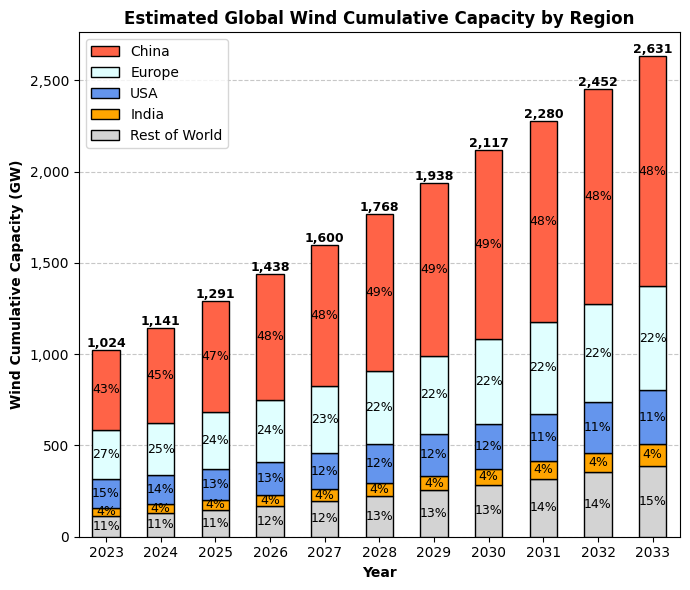

In [48]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

# Load the dataset
df = pd.read_csv('data/deployment.csv')

# Set the "Year" column as the index (optional, but it makes the x-axis cleaner)
df.set_index('Year', inplace=True)

# Reorder the columns explicitly
column_order = ['Rest of World', 'India', 'USA', 'Europe', 'China']
df = df[column_order]

# Convert the data from MW to GW (divide by 1000)
df = df / 1000  # Now the values are in GW

# Filter the data to show only the years from 2024 to 2033
df = df.loc[2023:2033]

# Define the custom colors for each region
colors = {
    'Rest of World': 'lightgrey',
    'India': 'orange',
    'USA': 'cornflowerblue',
    'Europe': 'lightcyan',
    'China': 'tomato'
}

# Plot the stacked bar chart with custom colors
ax = df.plot(kind='bar', stacked=True, figsize=(7, 6), edgecolor='black', zorder=100, color=[colors[col] for col in df.columns])

# Reverse the order of the legend
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[::-1], labels[::-1])

# Add horizontal grid lines
ax.grid(True, axis='y', linestyle='--', alpha=0.7, zorder=1)

# Format y-axis with commas for the thousands
formatter = FuncFormatter(lambda x, pos: f'{int(x):,}')
ax.yaxis.set_major_formatter(formatter)

# Add text on top of each bar with the total value in GW
for i in range(len(df)):
    total = df.iloc[i].sum()  # Sum the values of the stacked bar for each year
    ax.text(i, total, f'{int(total):,}', ha='center', va='bottom', fontsize=9, fontweight='bold')

    # Add percentage text in the middle of each stacked bar segment
    cumulative_sum = 0
    for j, region in enumerate(df.columns):
        # Calculate percentage for each region
        region_value = df.loc[df.index[i], region]
        percentage = (region_value / total) * 100
        # Position the text in the center of each stacked bar segment
        cumulative_sum += region_value
        ax.text(i, cumulative_sum - region_value / 2, f'{percentage:.0f}%', ha='center', va='center', fontsize=9, zorder=1000)

# Customize the plot
plt.title('Estimated Global Wind Cumulative Capacity by Region', fontweight='bold')
plt.xlabel('Year', fontweight='bold')
plt.ylabel('Wind Cumulative Capacity (GW)', fontweight='bold')
plt.xticks(rotation=0)  # Rotate the x-axis labels for better visibility
plt.tight_layout()  # Adjust layout to avoid overlap

plt.savefig("figures/woodmac_deployment.svg", format="svg", dpi=300)

# Show the plot
plt.show()
